# 02 · Feature engineering as a research gate

**Current decision: competition performance remains open.** The original lexical submission scored **0.59191 public / 0.61956 private**, below the approximately **0.92** objective. A successful submission did not complete the performance goal. The historical research below used post-competition development labels and remains a separate, preserved result. The new original-data representation study reopens the feature gate; [the rebuild record](../docs/COMPETITION_REBUILD.md) explains the failure and next acceptance steps.

In [1]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
import plotly.io as pio
from jigsaw_rules.review import public_evidence
from jigsaw_rules.runtime import environment

# Every figure also supplies an SVG fallback. Keep JavaScript bundles out of the notebook.
pio.renderers.default = "plotly_mimetype"

root = Path(os.environ.get("JIGSAW_ROOT", Path.cwd())).resolve()
if root.name == "notebooks":
    root = root.parent
baseline = public_evidence(root, "baseline")
semantic = public_evidence(root, "semantic")
assert baseline["training_sha256"] == semantic["training_sha256"]
print("Historical references: 2,029 rows, two policies; expanded research is a separate cohort.")
print("Aggregate checksums verified. This notebook performs no model fitting.")
protocols = {"seen_rule": "Familiar rules", "heldout_rule": "Held-out rule"}

def metric_table(records, heldout=False):
    return pd.DataFrame([{"Representation": r["model"], "Validation": protocols[r["protocol"]],
        "Rule macro AUC": r["metrics"]["rule_macro_auc"],
        "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"],
        "Average precision": r["metrics"]["average_precision"]}
        for r in records if not heldout or r["protocol"] == "heldout_rule"]).round(4)


Historical references: 2,029 rows, two policies; expanded research is a separate cohort.
Aggregate checksums verified. This notebook performs no model fitting.


In [2]:
import sys
sys.path.insert(0, str(root / "scripts"))
from build_research_report import display_figure
from build_release_report import display_boundary
from jigsaw_rules.features import feature_evidence
from jigsaw_rules.research import research_evidence
from jigsaw_rules.diagnostics import diagnostic_evidence
from jigsaw_rules.pairs import pairs_evidence
from jigsaw_rules.robustness import robustness_evidence
from jigsaw_rules.gate import feature_gate
from jigsaw_rules.instructions import instruction_evidence
from jigsaw_rules.released import released_evidence
from jigsaw_rules.expanded import expanded_evidence
from jigsaw_rules.retrieval import retrieval_evidence
from jigsaw_rules.resolution import resolution_evidence
from jigsaw_rules.formatting import formatting_evidence
from jigsaw_rules.feature_decision import decision_evidence
from build_expanded_report import display_figure as display_expanded
from build_formatting_report import display_figure as display_formatting

expanded = expanded_evidence(root)
retrieval = retrieval_evidence(root)
resolution = resolution_evidence(root)
formatting = formatting_evidence(root)
decision = decision_evidence(root)
assert expanded is not None and retrieval is not None and resolution is not None
assert formatting is not None and decision is not None
controls = feature_evidence(root)
research = research_evidence(root)
sensitivity = diagnostic_evidence(root)
pairs = pairs_evidence(root)
robustness = robustness_evidence(root)
assert all(item is not None for item in (controls, research, sensitivity, pairs, robustness))
gate = feature_gate(root)
instructions = instruction_evidence(root)
released = released_evidence(root)
assert released is not None
print("Verified expanded study:", expanded["metadata"]["run_id"])


Verified expanded study: a57bb74350fcbcd66592


## Competition rebuild: richer rule and example representations

**Question:** At a fixed 4B backbone and classifier, do joint context and representation interactions improve policy transfer? The extractor never receives development targets. All learned screens and classifiers fit inside purged training folds. These are repeated development measurements on two policies, not a new holdout or a Kaggle score. The original lexical submission remains the recorded baseline.

Inference run: fe1da83fc62341bf608d
Unique candidate columns: 15369
Fixed classifier fits: 45


,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,lexical_reference,Held-out rule,0.6156,0.6736,0.2405,0.6241
1,rule_raw,Held-out rule,0.7081,6.0601,0.4342,0.6647
2,support_raw,Held-out rule,0.5747,3.4501,0.4540,0.5811
3,rule_support_raw,Held-out rule,0.7056,5.5933,0.4393,0.6671
4,rule_likelihood,Held-out rule,0.7021,0.7774,0.2824,0.5701
5,rule_embedding,Held-out rule,0.5508,1.1337,0.3541,0.4937
6,support_likelihood,Held-out rule,0.3644,0.8485,0.3205,0.4181
7,support_embedding,Held-out rule,0.5312,0.8915,0.3133,0.5027
8,rule_support_likelihood,Held-out rule,0.6903,0.8246,0.2959,0.5971
9,rule_support_embedding,Held-out rule,0.4881,1.7367,0.4570,0.4694


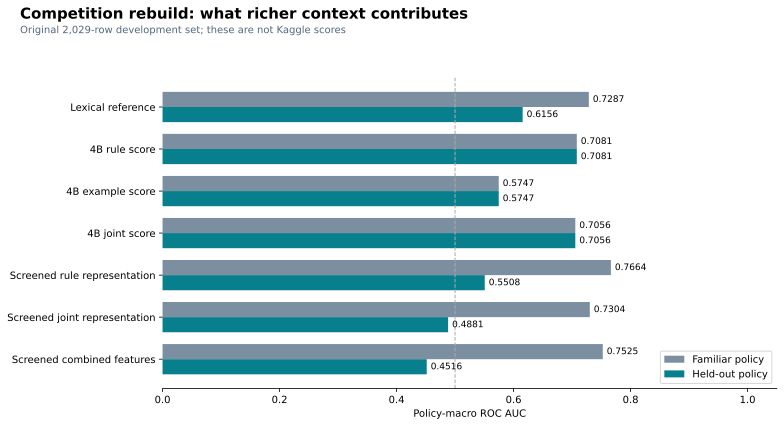

In [3]:
import sys
sys.path.insert(0, str(root / 'scripts'))
from build_competition_report import evidence as competition_evidence, display_comparison
competition = competition_evidence(root)
print('Inference run:', competition['provenance']['inference_run_id'])
print('Unique candidate columns:', competition['protocol']['unique_candidates'])
print('Fixed classifier fits:', competition['protocol']['fixed_classifier_fits'])
display(metric_table(competition['results'], heldout=True))
display_comparison(root)

### Feature attribution and screening
The rule-score comparison against TF-IDF changes the model. The context and representation contrasts below hold the 4B backbone fixed. Simultaneous intervals cover the declared contrasts within this study; they do not remove selection across earlier experiments. Candidate counts are per bank, with overlap across combined banks; only the unique total above may be used for overall feature-count claims.

In [4]:
counts = pd.DataFrame(competition['screening'])
display(counts.groupby(['protocol', 'bank'])[['candidates', 'retained', 'rejected']].agg(['min', 'max']))
contrasts = pd.DataFrame(competition['uncertainty'])
display(contrasts[['protocol', 'contrast', 'observed_delta', 'simultaneous_lower', 'simultaneous_upper']].round(4))
print('Self-support overlap rows:', competition['protocol']['self_support_overlap_rows'])
print('Every result also records metrics excluding these rows.')
for limitation in competition['protocol']['limitations']:
    print('-', limitation)

Self-support overlap rows: 18
Every result also records metrics excluding these rows.
- Two development policies only; four hidden new policies untested here.
- Purging reduces training size; absolute CV is not an LB forecast.
- Old 0.6B comparisons change the model, prompt, and field budgets.
- Feature contrasts hold the 4B model and classifier settings fixed.
- No tuning on the already-consumed post-competition protected evaluation.


candidates         ... rejected       
                                            min    max  ...      min    max
protocol     bank                                       ...                
heldout_rule all_features                 15369  15369  ...    15305  15305
             all_likelihood                   9      9  ...        2      3
             context_interactions          7680   7680  ...     7616   7616
             rule_embedding                2560   2560  ...     2496   2496
             rule_likelihood                  3      3  ...        1      1
             rule_support_embedding        2560   2560  ...     2496   2496
             rule_support_likelihood          3      3  ...        1      1
             support_embedding             2560   2560  ...     2496   2496
             support_likelihood               3      3  ...        0      1
seen_rule    all_features                 15369  15369  ...    15305  15305
             all_likelihood                   9      9  ...        3      3
             context_interactions          7680   7680  ...     7616   7616
             rule_embedding                2560   2560  ...     2496   2496
             rule_likelihood                  3      3  ...        1      1
             rule_support_embedding        2560   2560  ...     2496   2496
             rule_support_likelihood          3      3  ...        1      1
             support_embedding             2560   2560  ...     2496   2496
             support_likelihood               3      3  ...        1      1

[18 rows x 6 columns]

,protocol,contrast,observed_delta,simultaneous_lower,simultaneous_upper
0,seen_rule,4B rule score versus lexical,-0.0205,-0.0563,0.0153
1,seen_rule,supplied context at fixed model,-0.0026,-0.0384,0.0333
2,seen_rule,joint versus rule representation,-0.0361,-0.0719,-0.0002
3,seen_rule,interaction bank contribution,0.0222,-0.0136,0.0580
4,seen_rule,learned representation versus direct score,0.0469,0.0111,0.0828
5,heldout_rule,4B rule score versus lexical,0.0926,0.0476,0.1376
6,heldout_rule,supplied context at fixed model,-0.0026,-0.0476,0.0424
7,heldout_rule,joint versus rule representation,-0.0627,-0.1077,-0.0177
8,heldout_rule,interaction bank contribution,-0.0365,-0.0815,0.0085
9,heldout_rule,learned representation versus direct score,-0.2540,-0.2990,-0.2090


### What this does and does not close
A wide bank is useful only if its gains survive the matched ablations. The next section tests support-pair adaptation and adapted prototype/nearest-example features. The earlier protected cohort has already been evaluated and cannot become a tuning set. Read the measured decision in [Competition rebuild](../docs/COMPETITION_REBUILD.md) before promoting a new submission.

## Learn the new rule from its supplied examples

**Question:** Does task-specific representation learning improve genuinely novel comments when labeled supports for a new rule are available? This is a support-adaptation test, distinct from zero-shot transfer. The same 4B model and rule-only prompt are compared before and after one fixed epoch of LoRA. Query labels never enter the GPU input, and every query body is purged from all fitting sources. The classical readouts and prototype features use only that policy's known support labels.

The cohort contains 881 original-data comments across two previously examined policies; 1,148 comments present in a supplied support pool are excluded. This is development evidence, not a new untouched test or a Kaggle score. Frozen/adapted comparisons isolate representation learning, while prototype additions compare features at the same adapted backbone.

Cloud run: d13858b7407993fcc6e8
Novel evaluation comments: 881
Candidate coordinates and geometry columns: 5138
Policy 1: No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.
Policy 2: No legal advice: Do not offer or request legal advice.


,Representation,Policy-macro AUC,Policy 1 AUC,Policy 2 AUC
0,frozen_raw,0.6146,0.5705,0.6587
1,frozen_screened_embedding,0.6715,0.5855,0.7575
2,frozen_centroid,0.6434,0.5954,0.6914
3,frozen_nearest,0.6622,0.6028,0.7215
4,frozen_top5,0.7013,0.6644,0.7382
5,frozen_geometry_blend,0.6499,0.5994,0.7003
6,adapted_raw,0.7199,0.6793,0.7605
7,adapted_screened_embedding,0.7174,0.6754,0.7593
8,adapted_centroid,0.7185,0.6708,0.7661
9,adapted_nearest,0.6791,0.6385,0.7196


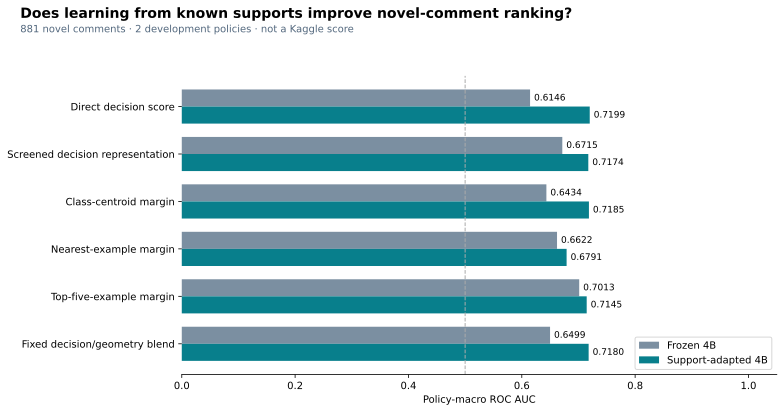

In [5]:
from build_adaptation_report import evidence as adaptation_evidence, display_comparison as display_adaptation
adaptation = adaptation_evidence(root)
print('Cloud run:', adaptation['inference']['run_id'])
print('Novel evaluation comments:', adaptation['protocol']['rows'])
print('Candidate coordinates and geometry columns:', adaptation['protocol']['unique_candidate_columns'])
policies = sorted(adaptation['results'][0]['metrics']['per_rule_auc'])
for i, policy in enumerate(policies, 1):
    print(f'Policy {i}:', policy)
comparison_rows = []
for record in adaptation['results']:
    comparison_rows.append({'Representation': record['model'], 'Policy-macro AUC': record['metrics']['rule_macro_auc'], **{f'Policy {i} AUC': record['metrics']['per_rule_auc'][policy] for i, policy in enumerate(policies, 1)}})
display(pd.DataFrame(comparison_rows).round(4))
display_adaptation(root)

### Attribute the gains and verify recovery
Each embedding screen starts with 2,560 candidate coordinates and retains at most 64 using fitting labels only. Prototype margins compare a query against known positive and negative centroids or neighbors; query labels are absent. The fixed rank blend gives half its weight to the decision score and one quarter each to centroid and nearest-example margins. Top-five margins are secondary diagnostics. Rank scores are not calibrated probabilities.

The paired intervals below cover five declared contrasts and condition on these two policies. Adapter/optimizer/scheduler/RNG/data-order recovery was tested by deliberately reloading a fresh GPU model after step 8 in each fold. The baseline feature replay also reused all 96 verified shards without model computation.

In [6]:
display(pd.DataFrame(adaptation['screening'])[['fold', 'model', 'candidates', 'retained', 'rejected']])
display(pd.DataFrame(adaptation['uncertainty'])[['contrast', 'observed_delta', 'simultaneous_lower', 'simultaneous_upper']].round(4))
probability_rows = [{'Model': r['model'], **r['raw_probability_diagnostics']} for r in adaptation['results'] if 'raw_probability_diagnostics' in r]
display(pd.DataFrame(probability_rows).round(4))
for fold in adaptation['inference']['folds']:
    print('Fold', fold['fold'], 'optimizer steps', fold['training']['optimizer_steps'], 'resumed at', fold['training']['resumed_step'], 'peak GPU GiB', round(fold['peak_gpu_gib'], 2))
for limitation in adaptation['protocol']['limitations']:
    print('-', limitation)

Fold 0 optimizer steps 142 resumed at 8 peak GPU GiB 8.27
Fold 1 optimizer steps 99 resumed at 8 peak GPU GiB 8.31
- Previously examined original policies; not an untouched test.
- Only novel comments absent from the supplied support pool are evaluated.
- Support adaptation differs from zero-shot held-out-rule CV.
- One LoRA configuration and two rules cannot establish 0.92 hidden-policy AUC.
- Feature contrasts hold the backbone and adaptation inputs fixed.
- Rank scores preserve log-odds order; rank blends are not calibrated.


,fold,model,candidates,retained,rejected
0,0,frozen,2560,64,2496
1,0,adapted,2560,64,2496
2,1,frozen,2560,64,2496
3,1,adapted,2560,64,2496


,contrast,observed_delta,simultaneous_lower,simultaneous_upper
0,support adaptation at fixed backbone,0.1053,0.0612,0.1493
1,adapted coordinates at fixed readout,0.0459,0.0018,0.0899
2,prototype blend contribution,-0.0019,-0.0460,0.0421
3,adapted class geometry,0.0751,0.0310,0.1191
4,screened representation versus answer,-0.0025,-0.0466,0.0415


,Model,log_loss,brier,ece_10_equal_width_bins
0,frozen_raw,4.8858,0.3756,0.3726
1,adapted_raw,0.7232,0.2292,0.1545


## Historical post-competition research

The preserved study below uses organizer-released labels and has its own consumed protected cohort. Its scores and stopping decision do not close the original-competition performance objective.

## 1 · The research question and protected boundary
The historical search covered two policies. The host's released corpus now permits 11,135 development rows across advertising, legal advice, medical advice and illegal-activity promotion. The 43,576 reserved rows include financial advice and spoilers, whose labels remain outside research. [Pre-score protocol](../docs/EXPANDED_STUDY.md) · [Data provenance](../docs/RELEASED_DATA.md).

Use three familiar-policy grouped folds and four held-out-policy folds. Every training body and supplied example is checked against validation bodies. Retain repeated annotations in the primary experiment; handle their influence through grouped validation and declared sensitivity analyses.

In [7]:
audit = expanded["audit"]
print("Protocol commit:", expanded["metadata"]["protocol_commit"])
print("Development rows / policies:", audit["development_rows"], audit["development_policies"])
print("Primary / total fitted models:", audit["primary_fitted_models"], audit["actual_fitted_models"])
print("Confirmation labels accessed during feature research:", audit["confirmation_labels_accessed"])
display(pd.DataFrame(audit["folds"])[["protocol", "fold", "training_rows", "validation_rows", "purged_training_rows"]])

Protocol commit: 5c16f91c04880d52280bf5a0a71ff688b327bb70
Development rows / policies: 11135 4
Primary / total fitted models: 238 260
Confirmation labels accessed during feature research: False


,protocol,fold,training_rows,validation_rows,purged_training_rows
0,seen_rule,0,3000,3712,4423
1,seen_rule,1,2643,3712,4780
2,seen_rule,2,2936,3711,4488
3,heldout_rule,0,5277,3152,2706
4,heldout_rule,1,5925,3383,1827
5,heldout_rule,2,8418,2389,328
6,heldout_rule,3,8289,2211,635


## 2 · Search broadly, with a reason for each family
Words and character patterns capture phrasing and morphology. Style measures test requests, links and emphasis. Rule/support similarities, token products and semantic geometry test whether the comment resembles prohibited examples more than permitted ones. Training-reference ranks test relative position; community frequencies and cross-fitted target context test group effects and shortcut risk.

The encoder is already rule-conditioned. Its raw coordinates, support products and compact scalar comparisons are separate representations. Full-vocabulary, NB-weighted and five fixed SVD controls test whether screening or representation scale explains an apparent gain. [Detailed family rationale, availability and leakage analysis](../docs/FEATURE_RESEARCH.md#candidate-space-and-availability).

No timestamps, author histories, threads, opponents, coaches or ratings exist in the schema. Temporal and historical sports/customer-style features would invent unavailable information.

Retained widths describe separate banks, not the selected centroid.


All candidates  All retained  All rejected
protocol     fold                                            
heldout_rule 0             188596          9497        179099
             1             188598          9403        179195
             2             188598          9629        178969
             3             188598          9660        178938
seen_rule    0             188597          9293        179304
             1             188596          9281        179315
             2             188595          9320        179275

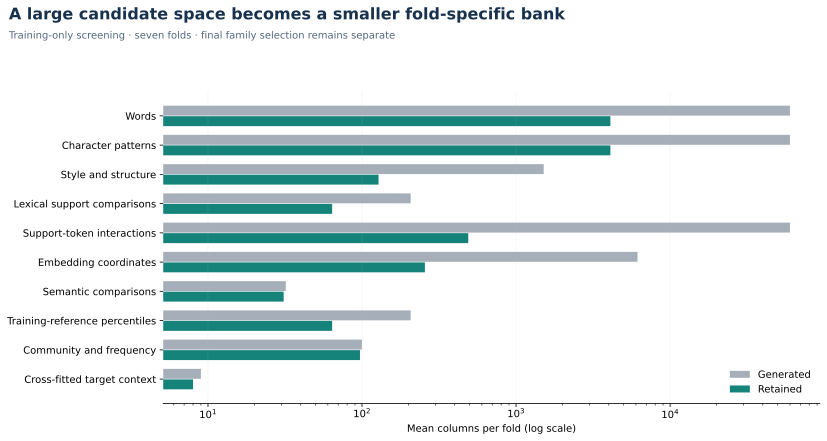

In [8]:
screens = pd.DataFrame(expanded["screening"]["families"] + retrieval["screening"] + formatting["screening"])
assert (screens.candidates == screens.retained + screens.rejected).all()
totals = screens.groupby(["protocol", "fold"])[["candidates", "retained", "rejected"]].sum()
display(totals.rename(columns={"candidates": "All candidates", "retained": "All retained", "rejected": "All rejected"}))
print("Retained widths describe separate banks, not the selected centroid.")
display_expanded(root, "screening")

## 3 · Fit every learned transform inside training
Vocabulary/IDF, rarity and redundancy decisions, effect-score screening, scaling, ranks, NB weights and SVD use the purged outer-training rows. Target/context features use inner grouped cross-fitting and inner text purging. Unknown groups fall back to inner-training priors. No validation target selects a column.

A retained bank is not a final feature set: each model consumes only its declared families. The full candidate catalogs, selected names and training IDs remain checksummed private artifacts. Logistic regression stays at C=2; no hyperparameter search compensates for weak representations.

In [9]:
decisions = pd.DataFrame([{"protocol": row["protocol"], "fold": row["fold"], "family": row["family"], **row["decisions"]} for row in expanded["screening"]["families"]]).fillna(0)
display(decisions.drop(columns=["protocol", "fold"]).groupby("family").sum().astype(int))

,rare,screen_budget,constant_or_near_constant,retained,exact_duplicate,high_training_correlation
family,,,,,,
character,123446,142553,60124,28672,65205,0
community,20,0,0,679,0,0
lexical,0,1000,0,448,0,1
ranks,0,753,0,448,239,9
semantic,0,41216,0,1792,0,0
semantic_scalar,0,0,0,217,0,7
structure,0,6844,2394,896,214,236
support_tokens,7441,0,409064,3428,67,0
target_context,0,0,7,56,0,0


## 4 · Attribute improvement through matched additions and removals
Each addition starts from the same screened-word model. Each removal starts from the same all-transfer representation. These contrasts test incremental utility, while comparisons with the historical-style reference also change representation/scaling conventions. Paired normalized-body bootstrap draws share weights across models; simultaneous intervals cover the declared contrasts. They condition on fixed OOF predictions and four observed policies, not arbitrary future rules or all adaptive research decisions.

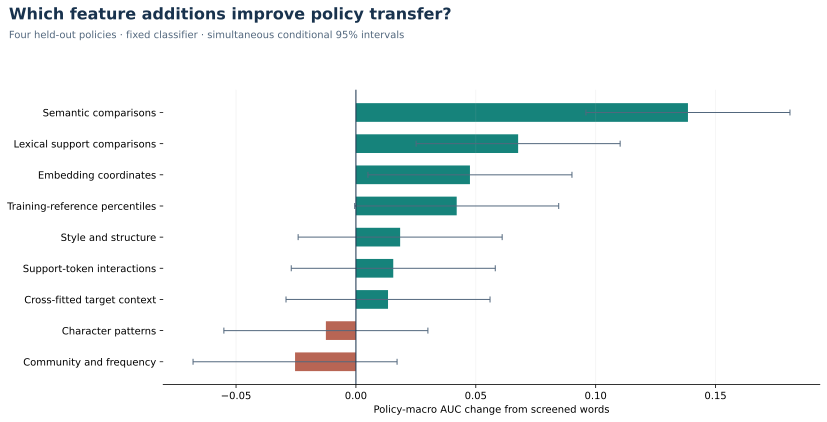

,contrast,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
112,remove_character,-0.0396,-0.0488,-0.0299,-0.0821,0.0030
113,remove_structure,0.0066,0.0014,0.0121,-0.0359,0.0492
114,remove_lexical,0.0021,-0.0046,0.0092,-0.0404,0.0447
115,remove_support_tokens,0.0080,0.0018,0.0138,-0.0345,0.0506
116,remove_semantic_scalar,0.0284,0.0206,0.0366,-0.0142,0.0709
117,remove_ranks,0.0020,-0.0002,0.0039,-0.0406,0.0445


In [10]:
display_expanded(root, "ablation")
contrasts = pd.DataFrame(expanded["uncertainty"])
removals = contrasts[(contrasts.protocol == "heldout_rule") & contrasts.contrast.str.startswith("remove_")]
display(removals[["contrast", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))

## 5 · Check whether the selected signals are stable
Selection overlap measures whether folds retain the same columns; it does not establish usefulness. Group permutation shuffles each group's linear contribution within policy, preserving policy prevalence. Correlated families can substitute for one another, so the direct ablations remain the primary contribution evidence. Transparent linear contributions make a second SHAP plot unnecessary here.

In [11]:
stability = pd.DataFrame(expanded["screening"]["stability"])
display(stability[stability.protocol == "heldout_rule"].groupby("family").retained_jaccard.agg(["min", "mean", "max"]).round(3))
importance = pd.DataFrame([{**r, "mean_permutation_auc_drop": sum(r["within_rule_permutation_auc_drops"]) / len(r["within_rule_permutation_auc_drops"])} for r in expanded["importance"] if r["protocol"] == "heldout_rule" and r["model"] == "all_transfer"])
display(importance.groupby("family")[["mean_absolute_logit_contribution", "mean_permutation_auc_drop"]].mean().round(4))

,min,mean,max
family,,,
character,0.120,0.330,0.515
community,0.921,0.960,1.000
lexical,0.320,0.522,0.882
ranks,0.049,0.327,0.753
semantic,0.043,0.192,0.519
semantic_scalar,1.000,1.000,1.000
structure,0.113,0.286,0.561
support_tokens,0.419,0.624,0.814
target_context,1.000,1.000,1.000


,mean_absolute_logit_contribution,mean_permutation_auc_drop
family,,
character,0.9270,-0.0106
lexical,0.6020,0.0417
ranks,0.2268,0.0075
semantic_scalar,0.3772,0.0723
structure,1.7584,0.0536
support_tokens,0.2898,0.0061
word,1.6849,-0.0809


## 6 · Challenge duplicate, label and support dependence
Training-conflict exclusions use training labels only. Near-copy removal uses text only and fixed character-cosine/Jaccard thresholds. The validation rows stay fixed for both refits. Separately, descriptive metrics give equal total weight to each body/policy group or exclude conflicting groups from scoring. None of these diagnostic outcomes changes the primary folds.

The centroid stress tests average all four one-positive/one-negative example choices, shuffle supplied contexts within policy, and exclude exact self-support matches. They test dependence on the supplied examples; they do not establish paraphrase independence or resilience to absent rule text.

In [12]:
filters = pd.DataFrame(audit["training_sensitivities"])
filters["removed"] = filters.before - filters.after
display(filters.groupby(["protocol", "sensitivity", "model"])[["removed", "reused_primary"]].sum())
robust_records = [r for r in expanded["results"] if r["model"] in ["rule_examples", "character_full", "qwen_centroid"] or "exclude_conflicts" in r["model"] or "purge_near_copies" in r["model"]]
display(metric_table(robust_records, heldout=True))
display(pd.DataFrame([{ "Model": r["model"], "Primary AUC": r["metrics"]["rule_macro_auc"], "Equal group weight": r["equal_body_policy_weight"]["rule_macro_auc"], "Exclude conflicting groups": r["excluding_conflicts"]["rule_macro_auc"]} for r in robust_records if r["protocol"] == "heldout_rule"]).round(4))

removed  reused_primary
protocol     sensitivity       model                                  
heldout_rule exclude_conflicts character_full      549               0
                               rule_examples       549               0
             purge_near_copies character_full        1               3
                               rule_examples         1               3
seen_rule    exclude_conflicts character_full       26               0
                               rule_examples        26               0
             purge_near_copies character_full       69               0
                               rule_examples        69               0

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,character_full,Held-out rule,0.4464,0.9169,0.3345,0.5221
1,character_full_exclude_conflicts,Held-out rule,0.4469,0.9176,0.3347,0.5220
2,character_full_purge_near_copies,Held-out rule,0.4464,0.9170,0.3346,0.5220
3,qwen_centroid,Held-out rule,0.7042,0.6237,0.2177,0.7559
4,rule_examples,Held-out rule,0.4728,0.8126,0.2992,0.5294
5,rule_examples_exclude_conflicts,Held-out rule,0.4722,0.8144,0.2998,0.5278
6,rule_examples_purge_near_copies,Held-out rule,0.4731,0.8126,0.2992,0.5294


,Model,Primary AUC,Equal group weight,Exclude conflicting groups
0,character_full,0.4464,0.4494,0.4469
1,character_full_exclude_conflicts,0.4469,0.4497,0.4474
2,character_full_purge_near_copies,0.4464,0.4494,0.4469
3,qwen_centroid,0.7042,0.6949,0.7053
4,rule_examples,0.4728,0.4761,0.4730
5,rule_examples_exclude_conflicts,0.4722,0.4754,0.4725
6,rule_examples_purge_near_copies,0.4731,0.4765,0.4733


## 7 · Keep negative findings and scope limits visible
The original two-policy study also tested a frozen DeBERTa NLI cross-encoder and three fixed Qwen instruction-likelihood templates. Neither improved its lexical reference. These are useful negative findings for those models, inputs and policies; they do not establish failure on every policy. The expanded study tests the existing broad families and representation controls, rather than quietly attributing new-policy results to unexecuted NLI/instruction experiments.

In [13]:
historical = [r for r in pairs["results"] if r["model"] in ["rule_nli", "word_nli", "all_nli"]]
if instructions is not None:
    historical += instructions["results"]
print("Historical two-policy evidence only:")
display(metric_table(historical, heldout=True))

Historical two-policy evidence only:


,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,rule_nli,Held-out rule,0.5474,0.7257,0.2633,0.5327
1,all_nli,Held-out rule,0.5602,0.7252,0.2631,0.5475
2,word_nli,Held-out rule,0.5964,0.6964,0.2475,0.6097
3,frozen_rule,Held-out rule,0.4504,0.8861,0.3301,0.4314
4,frozen_rule_support,Held-out rule,0.4488,0.8323,0.3081,0.4316
5,frozen_support,Held-out rule,0.4753,0.7432,0.2708,0.4667
6,instruction_features,Held-out rule,0.4808,0.7760,0.2859,0.4716
7,semantic_instruction,Held-out rule,0.5716,0.7812,0.2869,0.5335
8,word_instruction,Held-out rule,0.5755,0.6958,0.2495,0.5850


## 8 · Test a target-derived geometry hypothesis
The raw-coordinate and linear projection controls leave one plausible avenue: local neighborhoods and prototypes of labeled training examples. The preregistered retrieval extension uses three frozen geometric spaces and 309 neighborhood, prototype, nonlinear and supplied-margin interaction candidates. Training-only screening retains at most 64. It adds the family to four exact saved controls and also tests retrieval alone: 35 additional fixed fits.

Every labeled bank excludes the query policy, including familiar policies. Training features leave out each entire policy and purge reference body/support matches; validation transformation rejects a target column. Tests flip all labels of a query policy and prove its own feature rows are unchanged. This tests transferable geometry without assigning labels from one policy to another. [Protocol and rationale](../docs/RETRIEVAL_STUDY.md).

In [14]:
display(metric_table(retrieval["results"], heldout=True))
rc = pd.DataFrame(retrieval["uncertainty"])
display(rc[(rc.protocol == "heldout_rule") & rc.contrast.str.startswith("add_retrieval")][["contrast", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))
display(pd.DataFrame(retrieval["screening"])[["protocol", "fold", "candidates", "retained", "rejected"]])

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,all_transfer_retrieval,Held-out rule,0.5669,1.5584,0.4297,0.4865
1,retrieval_only,Held-out rule,0.5085,1.3773,0.3728,0.4837
2,semantic_retrieval,Held-out rule,0.5590,1.4763,0.3613,0.4923
3,word_retrieval,Held-out rule,0.4869,1.1316,0.3612,0.5593
4,word_semantic_retrieval,Held-out rule,0.5802,1.1566,0.3565,0.5435


,contrast,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
14,add_retrieval_to_word_screened,0.0493,0.0342,0.0659,0.0040,0.0945
15,add_retrieval_to_semantic_scalar_only,-0.1287,-0.1431,-0.1137,-0.1739,-0.0835
16,add_retrieval_to_word_semantic_scalar,0.0041,-0.0130,0.0211,-0.0412,0.0493
17,add_retrieval_to_all_transfer,0.0155,0.0035,0.0284,-0.0297,0.0607


,protocol,fold,candidates,retained,rejected
0,seen_rule,0,309,64,245
1,seen_rule,1,309,64,245
2,seen_rule,2,309,64,245
3,heldout_rule,0,309,64,245
4,heldout_rule,1,309,64,245
5,heldout_rule,2,309,64,245
6,heldout_rule,3,309,64,245


## 9 · Check the model's trained embedding resolutions
Matryoshka prefixes are different from learned SVD projections or arbitrary coordinate selection. Six preregistered resolutions (32–1,024 dimensions) reuse the same frozen vectors; smaller prefixes are normalized again. The 1,024-dimensional score must reproduce the existing centroid reference exactly. These are five additional scalar scoring controls, with zero new encoder calls or classifier fits—not thousands of new candidate columns. [Protocol and model-card rationale](../docs/RESOLUTION_STUDY.md).

In [15]:
display(pd.DataFrame([{ "Dimensions": r["dimension"], "Policy-macro AUC": r["metrics"]["rule_macro_auc"], "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"]} for r in resolution["results"]]).round(4))
display(pd.DataFrame(resolution["uncertainty"])[["candidate", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))

,Dimensions,Policy-macro AUC,Log loss,Brier
0,32,0.6848,0.6538,0.2290
1,64,0.6925,0.6498,0.2285
2,128,0.6899,0.6360,0.2233
3,256,0.6972,0.6295,0.2203
4,512,0.7001,0.6272,0.2192
5,1024,0.7042,0.6237,0.2177


,candidate,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
0,centroid_32,-0.0194,-0.0281,-0.0111,-0.0287,-0.0101
1,centroid_64,-0.0117,-0.0192,-0.0037,-0.0210,-0.0024
2,centroid_128,-0.0143,-0.0203,-0.0075,-0.0236,-0.0050
3,centroid_256,-0.0070,-0.0115,-0.0022,-0.0163,0.0023
4,centroid_512,-0.0041,-0.0070,-0.0013,-0.0134,0.0052


## 10 · Test the remaining semantic hypotheses
The preregistered extension compares instructed comment queries with plain support documents, and generic rule entailment with affirmative policy behavior. It adds 32 asymmetric and 45 intent candidates, four fixed models across seven folds, and three frozen scores. The original banks and controls are reused unchanged.

Plain supports lower centroid transfer AUC to 0.6865. Affirmative wording improves a weak generic NLI score from 0.4341 to 0.5174, still far below the centroid. Adding intent to semantic scalars gives only +0.0033 AUC with an interval spanning zero, while probability losses worsen. [Protocol and results](../docs/SEMANTIC_FORMATTING.md).

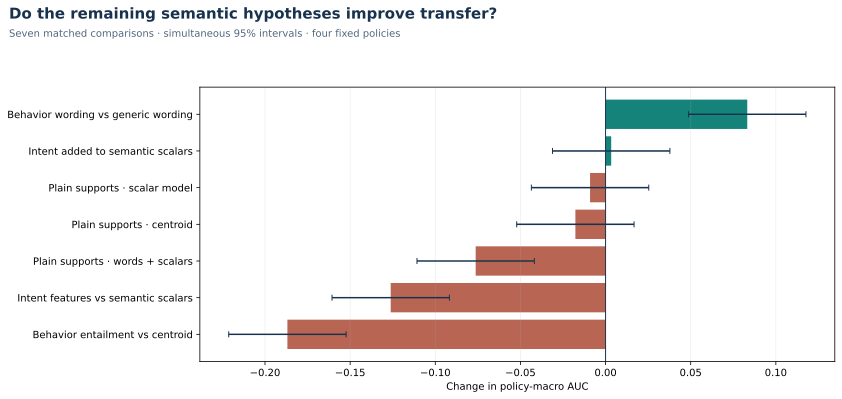

,protocol,fold,family,candidates,retained
0,seen_rule,0,asymmetric_scalar,32,30
1,seen_rule,0,intent_scalar,45,16
2,seen_rule,1,asymmetric_scalar,32,31
3,seen_rule,1,intent_scalar,45,16
4,seen_rule,2,asymmetric_scalar,32,31
5,seen_rule,2,intent_scalar,45,16
6,heldout_rule,0,asymmetric_scalar,32,30
7,heldout_rule,0,intent_scalar,45,16
8,heldout_rule,1,asymmetric_scalar,32,31
9,heldout_rule,1,intent_scalar,45,16


,min,mean,max
family,,,
asymmetric_scalar,0.875,0.964,1.000
intent_scalar,0.185,0.497,0.882


In [16]:
display_formatting(root, "contrasts")
display(pd.DataFrame(formatting["screening"])[["protocol", "fold", "family", "candidates", "retained"]])
stability = pd.DataFrame(formatting["audit"]["stability"])
display(stability.groupby("family").jaccard.agg(["min", "mean", "max"]).round(3))

## 11 · Explain the errors without relabeling them
Before seeing the new scores, a seeded 48-row legal/medical review examined speech act, policy behavior, context dependence and ambiguity. Every sampled body, policy and target matched its pinned source. Requests, personal experience, discussion and implicit advice can share vocabulary while differing in prohibited behavior.

This is a stratified qualitative review by one assistant, not independent human adjudication or a population label-error estimate. Twenty-three rows were flagged as ambiguous; none was relabeled. Raw text and row annotations remain private. The review motivated a falsifiable representation check, whose negative outcome remains visible.

In [17]:
review = formatting["error_audit"]
display(pd.Series(review["taxonomy_counts"]["speech_act"], name="Reviewed speech acts"))
display(pd.Series(decision["verification"], name="Private artifact replay"))

discussion              4
stating_information     9
advocating_harm         4
joke_or_insult          7
offering_advice        13
personal_experience     6
requesting_advice       5
Name: Reviewed speech acts, dtype: int64

run_id                           634ffc0b387c85f11041
files_verified                                    203
metric_records                                     20
model_prediction_replays                           28
feature_matrix_replays                             28
frozen_score_replays                                8
new_encoder_calls                                   0
new_model_fits                                      0
confirmation_targets_accessed                   False
Name: Private artifact replay, dtype: object

## 12 · Apply the stopping rule, including complementarity
The replacement criteria were committed before the new semantic scores: at least +0.005 macro AUC, a positive simultaneous lower bound, no policy loss above 0.02 AUC, and log-loss/Brier increases no larger than 0.01/0.005. None of seven alternatives passes. One separately preregistered 50/50 average checks whether centroid and semantic-intent scores complement each other; no weights or policy routing are tuned.

The average reaches 0.7086 AUC, but its +0.0044 gain is uncertain, advertising loses 0.0222, and both probability losses worsen. It fails all five conditions. Retain the simpler centroid. The [coverage ledger](../docs/FEATURE_COVERAGE.md) documents applicable families, exclusions and deferred model research; this is bounded evidence of diminishing returns, not universal feature exhaustion.

Final model fitting, nested calibration and the protected comparison are now complete; notebook `03` presents the accepted result. Verified offline integration remains required. The current standalone inference notebook remains the explicitly named lexical reference.

In [18]:
eligibility = decision["decision"]["candidate_eligibility"] + decision["fusion"]["decision"]["candidate_eligibility"]
display(pd.DataFrame([{ "Candidate": r["candidate"], "AUC": r["macro_auc"], "Gain": r["auc_gain"], "Eligible": r["eligible"], "Failed checks": ", ".join(r["failed_conditions"])} for r in eligibility]).round(4))

,Candidate,AUC,Gain,Eligible,Failed checks
0,asymmetric_centroid,0.6865,-0.0177,False,"practical_auc_gain, positive_simultaneous_inte..."
1,generic_entailment,0.4341,-0.2701,False,"practical_auc_gain, positive_simultaneous_inte..."
2,behavior_entailment,0.5174,-0.1868,False,"practical_auc_gain, positive_simultaneous_inte..."
3,asymmetric_scalar,0.6785,-0.0257,False,"practical_auc_gain, positive_simultaneous_inte..."
4,word_asymmetric_scalar,0.4998,-0.2044,False,"practical_auc_gain, positive_simultaneous_inte..."
5,intent_scalar,0.5615,-0.1427,False,"practical_auc_gain, positive_simultaneous_inte..."
6,semantic_intent,0.6909,-0.0133,False,"practical_auc_gain, positive_simultaneous_inte..."
7,centroid_intent_mean,0.7086,0.0044,False,"practical_auc_gain, positive_simultaneous_inte..."


In [19]:
display(pd.DataFrame(gate["criteria"]))
print("Final training justified:", gate["final_training_authorized_by_evidence"])
print(gate["decision"])

Final training justified: True
Feature research passed for the declared development scope. Retain the original Qwen centroid as the unseen-policy representation: the latest semantic alternatives and fixed average fail the predeclared replacement criteria. Final model training and calibration can now proceed under a frozen protocol. Reserved confirmation, offline promotion and a measured inference product remain incomplete.


,requirement,state
0,Broad candidate generation and training-only s...,verified
1,"Matched additions, removals, permutation and s...",verified
2,Unscreened controls and support-geometry alter...,verified
3,Joint comment-rule and support entailment repr...,verified
4,Self-support and approximate-copy stress tests,verified
5,Fixed instruction-likelihood and context ablat...,verified
6,Four-policy feature search and conflict/suppor...,verified
7,Policy-excluded target-derived semantic retrieval,verified
8,Matryoshka embedding-resolution sensitivity,verified
9,"Semantic formatting, policy intent and source-...",verified


## Reproduce the evidence
`python scripts/run_expanded.py --encode` extends only missing pinned embeddings, then resumes the preregistered study after the private research artifacts are restored. Omit `--encode` to require a complete verified cache. The default public notebook performs no fitting, downloads or target access. Sources, input identities, stage markers, full catalogs and OOF predictions are preserved. [Execution and restoration record](../docs/VALIDATION.md).